In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py

## Document with info to generate Flasks

https://docs.google.com/document/d/1y3QqozCy07UKOO9bxHti2Kk8n6Gqc5gUc6f1GZsNaSs/edit

### $n(z)$ path (from doc)

preliminary Y6 Metadetect /global/cfs/cdirs/des/y6-modeling/y6-data/nz/metadetect_y6_dndz_Feb2024.txt

preliminary Y6 Maglim /global/cfs/cdirs/des/y6-modeling/y6-data/nz/maglim_y6_dndz_Feb2024.txt

In [15]:
nz_path = '/global/cfs/cdirs/des/y6-modeling/y6-data/nz/'

#nz_meta = pd.read_csv(f'{nz_path}/metadetect_y6_dndz_Feb2024.txt')
nz_meta = np.loadtxt(f'{nz_path}/metadetect_y6_dndz_Feb2024.txt')
nz_mag = np.loadtxt(f'{nz_path}/maglim_y6_dndz_Feb2024.txt')

In [16]:
nz_meta.shape

(400, 5)

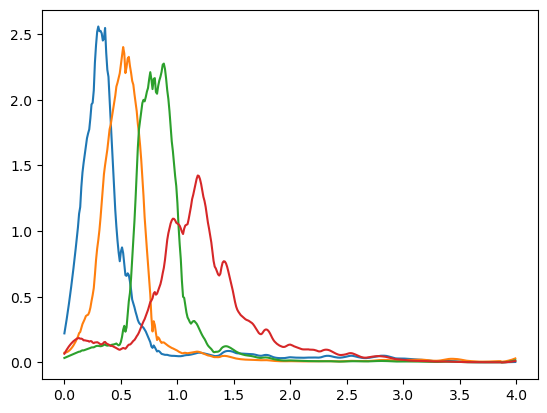

In [17]:
for i in range(1,5):
    plt.plot(nz_meta[:,0], nz_meta[:,i])

0.9999884075941423
0.9999995001429292
0.9999812565467119
0.9999927945196849
0.9999567097905839
0.9999652397840222


(0.0, 1.3)

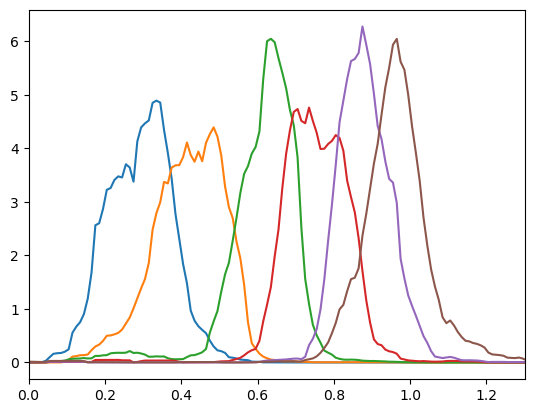

In [34]:
for i in range(1,7):
    plt.plot(nz_mag[:,0], nz_mag[:,i])
    nor = np.trapz(nz_mag[:,i], nz_mag[:,0])
    print(nor)
plt.xlim([0,1.3])

In [39]:
nz_mag[:,1:].shape

(601, 6)

0.13799840024799162
0.1015999492145216
0.10709799257615284
0.13809900492316848
0.10539543721192754
0.10449636755743032


(0.0, 1.3)

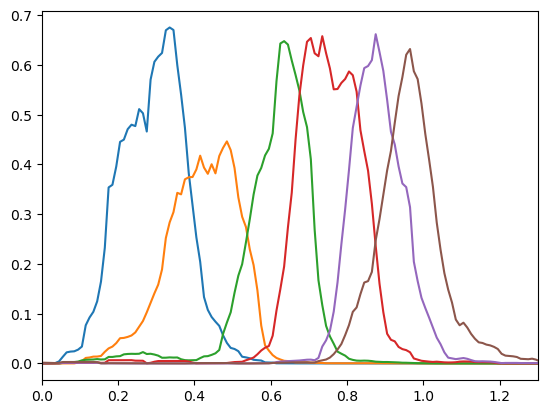

In [41]:
# renormalizing to match number densities

nor = np.array(
    [0.1380,0.1016,0.1071,0.1381,0.1054,0.1045]
)

nz_mag[:,1:] = nz_mag[:,1:]*nor

for i in range(1,7):
    plt.plot(nz_mag[:,0], nz_mag[:,i])
    newnor = np.trapz(nz_mag[:,i], nz_mag[:,0])
    print(newnor)
plt.xlim([0,1.3])

In [52]:
# saving

for i in range(1,7):
    np.savetxt(
        f'nl_3x2v2p0_f{i}.dat', 
        np.array((nz_mag[:,0], nz_mag[:,i])).T
    )

0.13799840024799162
0.1015999492145216
0.10709799257615284
0.13809900492316848
0.10539543721192754
0.10449636755743032


(0.0, 1.3)

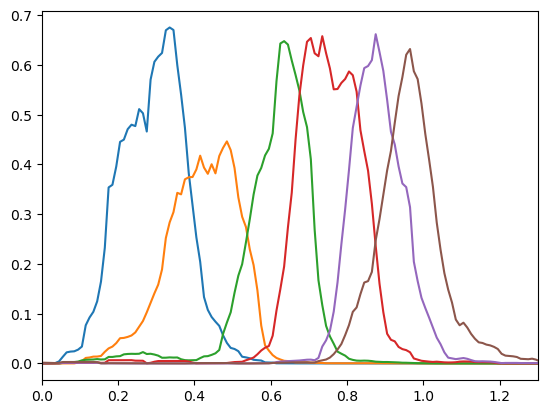

In [53]:
# testing new nz files

#nz_meta = pd.read_csv(f'{nz_path}/metadetect_y6_dndz_Feb2024.txt')
#nz_meta = np.loadtxt(f'{nz_path}/metadetect_y6_dndz_Feb2024.txt')

for i in range(1,7):
    nz_mag = np.loadtxt(f'nl_3x2v2p0_f{i}.dat')
    plt.plot(nz_mag[:,0], nz_mag[:,1])
    nor = np.trapz(nz_mag[:,1], nz_mag[:,0])
    print(nor)
plt.xlim([0,1.3])

In [3]:
date = '2024-07-15'
folder_cats = '/global/cfs/cdirs/des/y6kp-cats/' + date + '/'
master_file_path = folder_cats + "desy6kp_cats_%s.hdf5"%date

#############

master = h5py.File(master_file_path, 'r')
metadata_group = master["metadata"]

#############

path_sompz_mdet = metadata_group.attrs["path_mdet_sompz"]
print(path_sompz_mdet)
sompz_mdet = h5py.File(path_sompz_mdet, 'r')
sompz_mdet['sompz/pzdata/'].keys()

cols = sompz_mdet['sompz/pzdata/'].keys()
print(cols)
zlow = sompz_mdet['sompz/pzdata/zhigh'][:]
zhigh = sompz_mdet['sompz/pzdata/zlow'][:]
z = (zhigh-zlow)/2. + zlow

/global/cfs/cdirs/des/y6-redshift/sompz_v6_10000Tile_final_24-07-11.h5
<KeysViewHDF5 ['bin0', 'bin1', 'bin2', 'bin3', 'pz_c', 'pz_chat', 'zhigh', 'zlow']>


In [5]:
zhigh.shape

(300,)

In [75]:
!pip install healpy

/bin/bash: pip: command not found


In [6]:
import numpy as np
import healpy as hp
from astropy.io import fits

In [2]:
maskpath = '/global/cfs/projectdirs/des/monroy/Y6A2/maglim/joint_mask'

mask = fits.open(f'{maskpath}/maglim_joint_lss-shear_mask_nside1024_RING_v4.fits.gz')

In [3]:
data = mask[1].data

In [7]:
mask = np.zeros(hp.nside2npix(1024))
mask[data['HPIX']] = data['FRAC_DET_GRIZ']

ValueError: Passing parameters norm and vmin/vmax simultaneously is not supported. Please pass vmin/vmax directly to the norm when creating it.

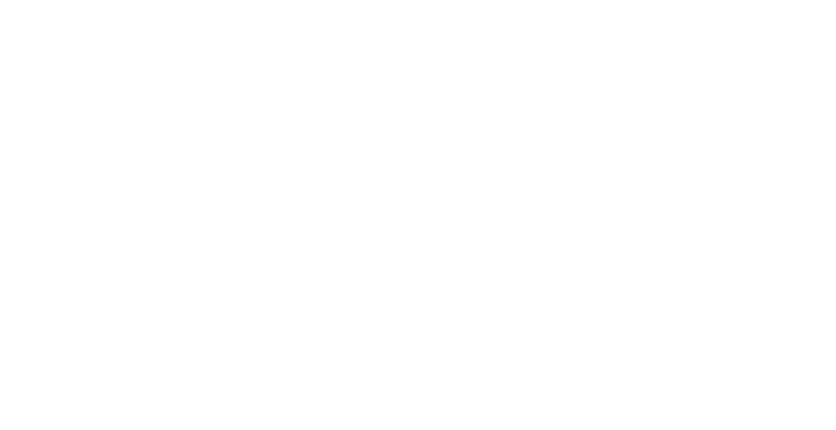

In [8]:
hp.mollview(mask)